# 08 - Velocity Error by Area

## 1. Purpose and Scope

This notebook compares how accurately RADAR and LiDAR estimate the velocity of surrounding vehicles across different **driving areas** (e.g. terminal, highway, city).

The overall velocity comparison in `05_comparison.ipynb` combines every scene in the dataset into a single result. However, sensor performance may depend on the driving environment. For example, a highway has faster traffic and longer distances, while a terminal or city has slower vehicles, more objects, and more structures nearby. Breaking the results down by area shows whether one sensor is more reliable in some environments than others.

Two types of error are measured for each sensor:

- **Speed error (m/s):** the difference between the speed estimated by the sensor and the reference speed.
- **Direction error (degrees):** the angle between the direction estimated by the sensor and the reference direction. Velocity has both a speed and a direction, so a sensor can estimate the speed correctly but still get the direction wrong. Direction error is only calculated for vehicles moving at 2 m/s or faster, since a stationary vehicle has no clear direction of travel.

The reference velocity is the annotation-derived velocity from `02_annotation_reference_velocity.ipynb`. The saved results in `results/validated/` are reused, so no sensor velocities are recalculated here.



In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Let the notebook find the src/ folder
sys.path.append(str(Path("..").resolve()))

from src.config import METADATA_ROOT
from src.area_velocity import (
    get_scene_tags_for_samples,
    add_scene_tags,
    add_direction_error,
    count_scenes,
    availability_by_area,
    error_summary,
)

print("Using metadata from:", METADATA_ROOT)

RESULTS_FOLDER = Path("../results/validated")
MIN_SPEED = 2.0  # m/s, minimum speed for checking direction

Using metadata from: D:\year 3 sem 2\CITS3200 - Professional Computing\Boeing-RADAR-Autonomous-\data\man-truckscenes\v1.2-mini


## 2. Adding Area Information to the Velocity Results

Each row in `comparison_df` represents one vehicle between two annotated frames. To group the results by area, each row is linked to the scene it came from, and the scene's area and weather tags are taken from the dataset metadata.

In [2]:
comparison_df = pd.read_pickle(RESULTS_FOLDER / "comparison_df.pkl")
vehicle_reference_df = pd.read_pickle(RESULTS_FOLDER / "vehicle_reference_df.pkl")

# Add area/weather to every row
sample_tags = get_scene_tags_for_samples(METADATA_ROOT)
df = add_scene_tags(comparison_df, vehicle_reference_df, sample_tags)

# Add the direction error for RADAR and LiDAR
df = add_direction_error(df, min_speed=MIN_SPEED)

print("Number of rows (vehicles):", len(df))
print("Number of scenes:", df["scene_token"].nunique())
df[["area", "weather", "radar_velocity_available", "lidar_velocity_available"]].head()

Number of rows (vehicles): 15743
Number of scenes: 10


,area,weather,radar_velocity_available,lidar_velocity_available
0,terminal,clear,True,True
1,terminal,clear,True,True
2,terminal,clear,False,True
3,terminal,clear,True,True
4,terminal,clear,True,True


## 3. Data Coverage per Area

Before comparing areas, the number of scenes in each area and their weather conditions are checked. If an area has very few scenes, or its scenes were mostly recorded in a particular weather condition, differences between areas may be caused by these factors rather than by the area itself.

In [4]:
count_scenes(df, "area", "weather")

weather,clear,overcast,rain,snow,All
area,,,,,
city,2,1,0,1,4
highway,1,2,1,0,4
terminal,1,0,1,0,2
All,4,3,2,1,10


The table below shows how often each sensors was able to produce a velocity estimate in each area

In [5]:
availability_by_area(df, "area")

,area,scenes,vehicles,radar_available_pct,lidar_available_pct
0,city,4,8029,15.2,47.7
1,highway,4,6276,15.3,45.7
2,terminal,2,1438,58.2,91.4


## 4. Velocity Error by Area

### 4.1 All Available Estimates

Each sensor is evaluated on every vehicle for which it produced a velocity estimate. Because RADAR and LiDAR do not always detect the same vehicles, the two sensors are evaluated on different sets of vehicles in this table.

In [6]:
error_summary(df, "area")

,area,sensor,scenes,vehicles,speed_err_median,speed_err_iqr,speed_err_std,moving_vehicles,dir_err_median,dir_err_p90
0,city,RADAR,4,1218,0.223,0.647,7.208,531,5.315,40.662
1,city,LiDAR,4,3826,0.229,0.439,0.652,1428,1.034,4.785
2,highway,RADAR,4,961,0.728,12.648,52.904,924,4.092,146.103
3,highway,LiDAR,4,2867,0.270,0.558,1.259,2762,0.473,2.017
4,terminal,RADAR,2,837,0.151,0.391,2.404,20,105.435,175.257
5,terminal,LiDAR,2,1314,0.128,0.323,0.964,54,1.480,8.854



### 4.2 Matched Comparison (Same Vehicles for Both Sensors)

To make the comparison fair, only vehicles where **both** RADAR and LiDAR produced a velocity estimate are kept. Both sensors are therefore evaluated on exactly the same vehicles, and this is used as the main result.

**Reading the table:**

- The **median** shows the typical error, and is used to compare which sensor is usually more accurate.
- The **IQR**, **standard deviation** and **90th percentile (p90)** show how consistent a sensor is. These values increase when a sensor sometimes produces very large errors.

In [7]:
error_summary(df, "area", both_sensors_only=True)

,area,sensor,scenes,vehicles,speed_err_median,speed_err_iqr,speed_err_std,moving_vehicles,dir_err_median,dir_err_p90
0,city,RADAR,4,1163,0.213,0.583,6.730,509,5.063,36.480
1,city,LiDAR,4,1163,0.234,0.461,0.699,509,0.942,3.340
2,highway,RADAR,4,926,0.701,11.926,45.646,889,3.762,146.574
3,highway,LiDAR,4,926,0.449,0.906,1.434,889,0.437,1.475
4,terminal,RADAR,2,810,0.147,0.373,2.319,14,92.443,158.302
5,terminal,LiDAR,2,810,0.145,0.383,1.125,14,2.841,13.717


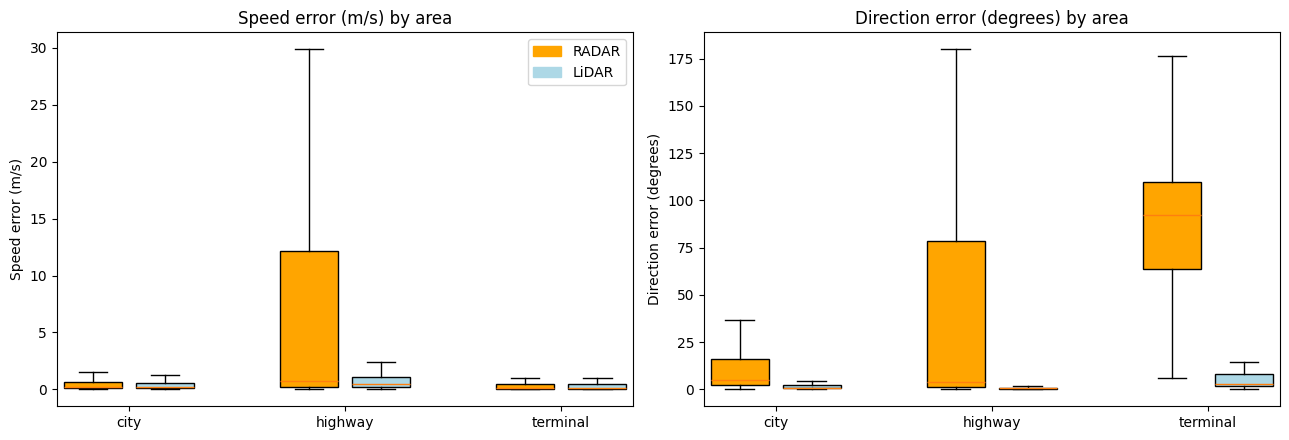

In [10]:
# Boxplots of the errors per area (same vehicles for both sensors)
both = df[df["radar_velocity_available"] & df["lidar_velocity_available"]]
areas = sorted(both["area"].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plots = [
    ("abs_error_2d_mps", "Speed error (m/s)"),
    ("dir_error_deg", "Direction error (degrees)"),
]

for ax, (column, title) in zip(axes, plots):
    for i, area in enumerate(areas):
        area_rows = both[both["area"] == area]
        radar = area_rows[f"radar_{column}"].dropna()
        lidar = area_rows[f"lidar_{column}"].dropna()

        # Draw RADAR and LiDAR boxes next to each other for each area
        box = ax.boxplot(
            [radar, lidar],
            positions=[i * 3, i * 3 + 1],
            widths=0.8,
            showfliers=False,   # hide extreme outliers so the boxes are readable
            patch_artist=True,
        )
        box["boxes"][0].set_facecolor("orange")
        box["boxes"][1].set_facecolor("lightblue")

    ax.set_xticks([i * 3 + 0.5 for i in range(len(areas))])
    ax.set_xticklabels(areas)
    ax.set_ylabel(title)
    ax.set_title(f"{title} by area")

axes[0].legend(
    [plt.Rectangle((0, 0), 1, 1, color="orange"), plt.Rectangle((0, 0), 1, 1, color="lightblue")],
    ["RADAR", "LiDAR"],
)
plt.tight_layout()
plt.show()

### 4.3 Clear Weather Only

To reduce the effect of weather, the matched comparison is repeated using only clear-weather scenes. This leaves fewer scenes per area, so the results are less representative but less affected by weather.

In [9]:
clear = df[df["weather"] == "clear"]

print(count_scenes(clear, "area", "weather"))
error_summary(clear, "area", both_sensors_only=True)

weather   clear  All
area                
city          2    2
highway       1    1
terminal      1    1
All           4    4


,area,sensor,scenes,vehicles,speed_err_median,speed_err_iqr,speed_err_std,moving_vehicles,dir_err_median,dir_err_p90
0,city,RADAR,2,668,0.276,1.023,7.869,306,7.973,43.975
1,city,LiDAR,2,668,0.284,0.468,0.650,306,1.038,3.159
2,highway,RADAR,1,142,7.441,26.496,56.552,142,62.057,175.270
3,highway,LiDAR,1,142,0.606,0.789,0.625,142,0.278,0.910
4,terminal,RADAR,1,570,0.220,0.516,2.725,14,92.443,158.302
5,terminal,LiDAR,1,570,0.216,0.496,1.281,14,2.841,13.717


## 5. Findings

### 5.1 How often each sensor produced a velocity

RADAR produced a velocity estimate for far fewer vehicles than LiDAR in every area. In the city and highway scenes, RADAR gave an estimate for about 15% of vehicles, compared with about 46–48% for LiDAR. Both sensors performed much better in the terminal scenes (58% for RADAR and 91% for LiDAR). A likely reason is that vehicles in a terminal are slower and closer to the truck, but the terminal group only contains 2 scenes, so this should be treated with caution.

### 5.2 Speed error

When both sensors are compared on the same vehicles (Section 4.2), their **typical** speed error is very similar in the city (0.21 m/s for RADAR vs 0.23 m/s for LiDAR) and in the terminal (0.15 m/s for both). On the highway, RADAR's typical error is higher (0.70 m/s vs 0.45 m/s).

The bigger difference is in **consistency**. RADAR's speed error is much more spread out than LiDAR's, especially on the highway, where the standard deviation is 45.6 m/s for RADAR compared with 1.4 m/s for LiDAR. This means RADAR is usually close to the correct speed, but occasionally gives an estimate that is very far off.

### 5.3 Direction error

LiDAR estimated the direction of travel more accurately than RADAR in every area. In the city, the typical direction error is about 5° for RADAR and under 1° for LiDAR. On the highway, it is about 4° for RADAR and under 0.5° for LiDAR.

RADAR also produced some very large direction errors. On the highway, 10% of RADAR estimates were off by more than 146°, meaning the estimated direction was almost opposite to the true direction. LiDAR's worst 10% stayed below 1.5°.

In the terminal, RADAR's typical direction error is around 92°, but this is based on only 14 moving vehicles, so it is not reliable enough to draw a conclusion.

### 5.4 Clear weather only

When only clear-weather scenes are used (Section 4.3), the same pattern appears: LiDAR is more accurate and more consistent in direction, and RADAR is least reliable on the highway. In the single clear highway scene, RADAR's typical speed error rises to 7.4 m/s and its typical direction error to 62°, compared with 0.6 m/s and 0.3° for LiDAR. Since this pattern also appears without bad weather, RADAR's weaker highway results do not seem to be caused by weather alone. However, this is based on only one highway scene.

### 5.5 Summary

| Area | Typical speed error | Consistency | Direction accuracy |
|---|---|---|---|
| City | Similar for both sensors | LiDAR more consistent | LiDAR better |
| Highway | LiDAR slightly better | LiDAR much more consistent | LiDAR much better |
| Terminal | Similar for both sensors | LiDAR more consistent | Too few moving vehicles to compare |

Overall, in this dataset, LiDAR gave more consistent velocity estimates than RADAR in every area, and the gap was largest on the highway. RADAR's typical speed error was often close to LiDAR's, but it produced more large errors, particularly in direction.

One possible explanation is that RADAR measures velocity only along the line between the sensor and the object. The full velocity has to be reconstructed from a small number of RADAR points, which becomes harder when a vehicle is far away or has only a few points on it, as is common on highways. This explanation was not tested in this notebook.



## 6. Limitations

- The mini dataset contains only a small number of scenes per area (see Section 3), so the results describe these specific scenes and cannot yet be generalised to each area type.
- Area and weather are not evenly distributed across scenes in the mini dataset. Section 4.3 reduces this effect but leaves very few scenes.
- Direction error only includes vehicles moving at 2 m/s or faster.
- The reference velocity is derived from annotated bounding boxes, which also contain some error.
- The analysis should be repeated on the selected trainval scenes before drawing firm conclusions.